# Extract

In [1]:
import pandas as pd
import time

In [2]:
path_main = 'https://github.com/KhalPrawira/Big-Data_Assignment/raw/refs/heads/main/UAS/Dataset/Pakistans%20Largest%20E-Commerce%20Dataset.csv'
path_holiday = 'https://github.com/KhalPrawira/Big-Data_Assignment/raw/refs/heads/main/UAS/Dataset/pakistan_holiday.csv'

def step_1_extract_raw():
    print("=== MULAI TAHAP 1: EXTRACT ===")
    
    # 1. BACA DATA UTAMA (E-COMMERCE)
    print("[1/3] Membaca file CSV Utama...")
    try:
        df_ecommerce = pd.read_csv(path_main, low_memory=False)
        print(f"   -> Sukses. Ukuran: {df_ecommerce.shape}")
        print("   -> Catatan: Kolom sampah (Unnamed) dan tanggal mentah ikut terbaca.")
    except Exception as e:
        print(f"   -> ERROR: {e}")
        return None, None, None

    # 2. BACA DATA KEDUA (HOLIDAY)
    print("[2/3] Membaca file CSV Holiday...")
    try:
        df_holiday = pd.read_csv(path_holiday)
        print(f"   -> Sukses. Ukuran: {df_holiday.shape}")
    except Exception as e:
        print(f"   -> ERROR: {e}")
        return None, None, None

    # 3. BUAT DATA KETIGA (JSON MAPPING)
    print("[3/3] Membuat Data Dummy JSON (Kategori)...")
    data_kategori = [
        {"category": "Mobiles & Tablets", "group": "Electronics"},
        {"category": "Superstore", "group": "Groceries"},
        {"category": "Women's Fashion", "group": "Fashion"},
        {"category": "Men's Fashion", "group": "Fashion"},
        {"category": "Appliances", "group": "Home & Living"},
        {"category": "Computing", "group": "Electronics"},
        {"category": "Beauty & Grooming", "group": "Health & Beauty"},
        {"category": "Soghaat", "group": "Gifts/Soghaat"},
        {"category": "Kids & Baby", "group": "Kids"},
        {"category": "Others", "group": "Others"}
    ]
    df_category_map = pd.DataFrame(data_kategori)
    print(f"   -> Sukses. Ukuran: {df_category_map.shape}")

    print("\n=== EXTRACT SELESAI ===")
    print("Data tersimpan di memori (variabel). JANGAN RESTART KERNEL sebelum lanjut ke tahap Load.")
    
    return df_ecommerce, df_holiday, df_category_map

df_raw_ecommerce, df_raw_holiday, df_raw_category = step_1_extract_raw()

=== MULAI TAHAP 1: EXTRACT ===
[1/3] Membaca file CSV Utama...
   -> Sukses. Ukuran: (1153432, 26)
   -> Catatan: Kolom sampah (Unnamed) dan tanggal mentah ikut terbaca.
[2/3] Membaca file CSV Holiday...
   -> Sukses. Ukuran: (60, 5)
[3/3] Membuat Data Dummy JSON (Kategori)...
   -> Sukses. Ukuran: (10, 2)

=== EXTRACT SELESAI ===
Data tersimpan di memori (variabel). JANGAN RESTART KERNEL sebelum lanjut ke tahap Load.


In [3]:
df_raw_ecommerce.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


# Load

In [4]:
from sqlalchemy import create_engine, text

## Koneksi ke Database

In [5]:
DB_CONFIG = {
    "user": "admin_k",
    "password": "My name is not Billy nor Alex",
    "host": "localhost",
    "port": "5432",
    "dbname": "ecommerce_dw"
}

connection_str = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
engine = create_engine(connection_str)

try:
    with engine.connect() as conn:
        print("✅ KONEKSI BERHASIL!")
        print(f"Terhubung ke database: {DB_CONFIG['dbname']}")
except Exception as e:
    print("❌ KONEKSI GAGAL!")
    print(f"Error: {e}")
    print("Pastikan container Docker sudah menyala ('Database Running').")

✅ KONEKSI BERHASIL!
Terhubung ke database: ecommerce_dw


## Load Dataset

### 1. Dataset Utama (E-Commerce)

In [6]:
print("--- [1/3] UPLOAD DATA E-COMMERCE ---")
start_time = time.time()

try:
    if 'df_raw_ecommerce' in locals():
        df_raw_ecommerce.to_sql('raw_ecommerce', engine, if_exists='replace', index=False)
        
        rows = len(df_raw_ecommerce)
        cols = len(df_raw_ecommerce.columns)
        print(f"✅ Sukses upload tabel 'raw_ecommerce'.")
        print(f"   Metadata: {rows} baris, {cols} kolom.")
    else:
        print("❌ Error: Variabel data tidak ditemukan. Jalankan Tahap Extract dulu!")
except Exception as e:
    print(f"❌ Gagal upload: {e}")

print(f"Waktu eksekusi: {time.time() - start_time:.2f} detik")

--- [1/3] UPLOAD DATA E-COMMERCE ---
✅ Sukses upload tabel 'raw_ecommerce'.
   Metadata: 1153432 baris, 26 kolom.
Waktu eksekusi: 170.69 detik


### 2. Dataset 2 (Holiday)

In [7]:
print("--- [2/3] UPLOAD DATA HOLIDAY ---")

try:
    if 'df_raw_holiday' in locals():
        df_raw_holiday.to_sql('raw_holiday', engine, if_exists='replace', index=False)
        print(f"✅ Sukses upload tabel 'raw_holiday'.")
        print(f"   Metadata: {len(df_raw_holiday)} baris.")
    else:
        print("❌ Error: Variabel data holiday tidak ditemukan.")
except Exception as e:
    print(f"❌ Gagal upload: {e}")

--- [2/3] UPLOAD DATA HOLIDAY ---
✅ Sukses upload tabel 'raw_holiday'.
   Metadata: 60 baris.


### 3. Dataset Tambahan (JSON)

In [8]:
print("--- [3/3] UPLOAD DATA CATEGORY MAP ---")

try:
    if 'df_raw_category' in locals():
        df_raw_category.to_sql('raw_category_map', engine, if_exists='replace', index=False)
        print(f"✅ Sukses upload tabel 'raw_category_map'.")
        print(f"   Metadata: {len(df_raw_category)} baris.")
    else:
        print("❌ Error: Variabel data kategori tidak ditemukan.")
except Exception as e:
    print(f"❌ Gagal upload: {e}")

--- [3/3] UPLOAD DATA CATEGORY MAP ---
✅ Sukses upload tabel 'raw_category_map'.
   Metadata: 10 baris.


## Validasi isi Database

In [9]:
print("--- VALIDASI FINAL: ISI DATABASE ---")

try:
    with engine.connect() as conn:
        print("\n[METADATA UKURAN DATA]")
        tables = ['raw_ecommerce', 'raw_holiday', 'raw_category_map']
        
        for tbl in tables:
            result = conn.execute(text(f"SELECT COUNT(*) FROM {tbl}"))
            count = result.scalar()
            print(f" -> Tabel '{tbl}': {count} baris")

        # Tampilkan Sampel Data Utama (Metadata Struktur)
        print("\n[PREVIEW TABEL UTAMA: raw_ecommerce ]")
        df_preview = pd.read_sql("SELECT * FROM raw_ecommerce LIMIT 5", conn)
        try:
            display(df_preview)
        except:
            print(df_preview)

        print("\n✅ LOAD SELESAI. Data tersimpan di PostgreSQL.")

except Exception as e:
    print(f"❌ Error saat preview: {e}")


--- VALIDASI FINAL: ISI DATABASE ---

[METADATA UKURAN DATA]
 -> Tabel 'raw_ecommerce': 1153432 baris
 -> Tabel 'raw_holiday': 60 baris
 -> Tabel 'raw_category_map': 10 baris

[PREVIEW TABEL UTAMA: raw_ecommerce ]


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,None,None,None,None,None
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,None,None,None,None,None
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,None,None,None,None,None
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,None,None,None,None,None
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,None,None,None,None,None



✅ LOAD SELESAI. Data tersimpan di PostgreSQL.


# Transform

## Transform Dimensi waktu

In [10]:
print("--- CEK STRUKTUR TABEL RAW_HOLIDAY ---")
with engine.connect() as conn:
    result = conn.execute(text("SELECT * FROM raw_holiday LIMIT 0"))
    print("Nama Kolom Asli:", result.keys())

--- CEK STRUKTUR TABEL RAW_HOLIDAY ---
Nama Kolom Asli: RMKeyView(['ADM_name', 'ISO3', 'Date', 'Name', 'Type'])


In [11]:
print("--- INSPEKSI DATA TANGGAL ---")
with engine.connect() as conn:
    print("\n1. Sampel Tanggal di E-COMMERCE (Tabel Utama):")
    res_main = conn.execute(text("SELECT DISTINCT created_at FROM raw_ecommerce LIMIT 5"))
    for row in res_main:
        print(f"   -> {row[0]}")

    print("\n2. Sampel Tanggal di HOLIDAY (Tabel Libur):")
    res_hol = conn.execute(text('SELECT DISTINCT "Date" FROM raw_holiday LIMIT 5'))
    for row in res_hol:
        print(f"   -> {row[0]}")

--- INSPEKSI DATA TANGGAL ---

1. Sampel Tanggal di E-COMMERCE (Tabel Utama):
   -> 10/10/2016
   -> 10/10/2017
   -> 10/11/2016
   -> 10/11/2017
   -> 10/1/2016

2. Sampel Tanggal di HOLIDAY (Tabel Libur):
   -> 2017-11-09
   -> 2016-07-09
   -> 2017-03-13
   -> 2016-10-12
   -> 2016-09-12


In [12]:
print("--- TRANSFORM PART 1: DIMENSI WAKTU ---")
start_time = time.time()

with engine.connect() as conn:
    # 1. SETUP SCHEMA
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS dwh;"))

    # 2. CREATE DIM_DATE
    query_dim_date = """
    DROP TABLE IF EXISTS dwh.dim_date CASCADE;
    
    CREATE TABLE dwh.dim_date AS
    SELECT DISTINCT
        -- 1. Cleaning E-Commerce (Coba Format YYYY-MM-DD standar Python)
        CAST(created_at AS DATE) as date_id,
        
        -- 2. Extraction
        EXTRACT(YEAR FROM CAST(created_at AS DATE)) as year,
        EXTRACT(MONTH FROM CAST(created_at AS DATE)) as month,
        EXTRACT(DAY FROM CAST(created_at AS DATE)) as day,
        TO_CHAR(CAST(created_at AS DATE), 'Day') as day_name,
        
        -- 3. Enrichment
        CASE 
            WHEN h."Name" IS NOT NULL THEN TRUE 
            ELSE FALSE 
        END as is_holiday,
        h."Name" as holiday_name
        
    FROM raw_ecommerce e
    -- JOIN: Kita ubah juga format Holiday menjadi DATE biasa
    -- (Postgres biasanya pintar mendeteksi format angka yyyy-mm-dd secara otomatis)
    LEFT JOIN raw_holiday h ON CAST(e.created_at AS DATE) = CAST(h."Date" AS DATE)
    WHERE created_at IS NOT NULL;
    """
    
    try:
        conn.execute(text(query_dim_date))
        conn.commit()
        print("✅ [SUKSES] Tabel 'dwh.dim_date' BERHASIL dibuat.")
        
        # Validasi
        res = conn.execute(text("SELECT count(*) FROM dwh.dim_date"))
        print(f"   -> Total Tanggal Unik: {res.scalar()}")
        
    except Exception as e:
        print(f"❌ ERROR: {e}")
        print("Jika error 'Date format not recognized', berarti formatnya memang unik.")

print(f"Waktu eksekusi: {time.time() - start_time:.2f} detik")

--- TRANSFORM PART 1: DIMENSI WAKTU ---
✅ [SUKSES] Tabel 'dwh.dim_date' BERHASIL dibuat.
   -> Total Tanggal Unik: 791
Waktu eksekusi: 4.28 detik


## Transform Dimensi Produk

In [13]:
print("--- TRANSFORM PART 2: DIMENSI PRODUK ---")
start_time = time.time()

query_dim_product = """
DROP TABLE IF EXISTS dwh.dim_product CASCADE;

CREATE TABLE dwh.dim_product AS
SELECT DISTINCT
    e.sku as product_id,
    e.category_name_1 as category_original,
    
    -- TRANSFORMATION: Grouping Category
    -- Logika: Jika ketemu di map, ambil nama grupnya. Jika tidak (null), isi 'Others'.
    -- Perhatikan: "group" adalah kata kunci SQL, jadi wajib pakai kutip dua.
    COALESCE(m."group", 'Others') as category_group

FROM raw_ecommerce e
-- Enrichment: Join dengan tabel mapping kategori
LEFT JOIN raw_category_map m ON e.category_name_1 = m.category
WHERE e.sku IS NOT NULL;
"""

with engine.connect() as conn:
    try:
        conn.execute(text(query_dim_product))
        conn.commit()
        print("✅ [SUKSES] Tabel 'dwh.dim_product' BERHASIL dibuat.")
        
        # Validasi
        res = conn.execute(text("SELECT count(*) FROM dwh.dim_product"))
        print(f"   -> Total Produk Unik: {res.scalar()}")
        
        # Cek sampel hasil grouping
        print("\n[Preview Kategori Grouping]")
        res_sample = conn.execute(text("SELECT category_original, category_group FROM dwh.dim_product LIMIT 5"))
        for row in res_sample:
            print(f"   Original: {row[0]}  -->  Group: {row[1]}")
            
    except Exception as e:
        print(f"❌ ERROR: {e}")
        print("Tips: Cek apakah nama kolom di raw_category_map sudah benar (category, group).")

print(f"Waktu eksekusi: {time.time() - start_time:.2f} detik")

--- TRANSFORM PART 2: DIMENSI PRODUK ---
✅ [SUKSES] Tabel 'dwh.dim_product' BERHASIL dibuat.
   -> Total Produk Unik: 84915

[Preview Kategori Grouping]
   Original: Mobiles & Tablets  -->  Group: Electronics
   Original: Beauty & Grooming  -->  Group: Health & Beauty
   Original: Mobiles & Tablets  -->  Group: Electronics
   Original: Men's Fashion  -->  Group: Fashion
   Original: Beauty & Grooming  -->  Group: Health & Beauty
Waktu eksekusi: 5.97 detik


## Transform Dimensi Customer

In [14]:
print("--- TRANSFORM PART 3: DIMENSI CUSTOMER ---")
start_time = time.time()

query_dim_customer = """
DROP TABLE IF EXISTS dwh.dim_customer CASCADE;

CREATE TABLE dwh.dim_customer AS
SELECT
    -- Ambil ID Customer (Pastikan nama kolom sesuai CSV asli, biasanya "Customer ID")
    "Customer ID" as customer_id,
    
    -- TRANSFORMATION: Aggregation
    -- Mencari tanggal paling awal (MIN) transaksi pelanggan tersebut
    MIN(CAST(created_at AS DATE)) as join_date,
    
    -- Menghitung total kali belanja (Frekuensi) - Bonus Info
    COUNT(item_id) as total_orders
    
FROM raw_ecommerce
WHERE "Customer ID" IS NOT NULL
GROUP BY "Customer ID"; -- Wajib GROUP BY karena ada fungsi Aggregasi (MIN/COUNT)
"""

with engine.connect() as conn:
    try:
        conn.execute(text(query_dim_customer))
        conn.commit()
        print("✅ [SUKSES] Tabel 'dwh.dim_customer' BERHASIL dibuat.")
        
        # Validasi
        res = conn.execute(text("SELECT count(*) FROM dwh.dim_customer"))
        print(f"   -> Total Customer Unik: {res.scalar()}")
        
        # Preview Data
        print("\n[Preview Data Customer]")
        res_sample = conn.execute(text("SELECT * FROM dwh.dim_customer LIMIT 5"))
        for row in res_sample:
            print(f"   ID: {row[0]} | Join Date: {row[1]} | Orders: {row[2]}")
            
    except Exception as e:
        print(f"❌ ERROR: {e}")
        print("Tips: Cek apakah nama kolom 'Customer ID' sudah benar (perhatikan spasi/kapital).")

print(f"Waktu eksekusi: {time.time() - start_time:.2f} detik")

--- TRANSFORM PART 3: DIMENSI CUSTOMER ---
✅ [SUKSES] Tabel 'dwh.dim_customer' BERHASIL dibuat.
   -> Total Customer Unik: 115326

[Preview Data Customer]
   ID: 65948.0 | Join Date: 2017-11-09 | Orders: 4
   ID: 90186.0 | Join Date: 2018-02-20 | Orders: 37
   ID: 18947.0 | Join Date: 2016-11-23 | Orders: 2
   ID: 79253.0 | Join Date: 2017-11-24 | Orders: 3
   ID: 111707.0 | Join Date: 2018-06-26 | Orders: 3
Waktu eksekusi: 3.11 detik


## Transform Tabel fact_sales

In [15]:
print("--- TRANSFORM PART 4: TABEL FAKTA (FINAL) ---")
start_time = time.time()

# Query ini cukup kompleks karena melakukan filtering dan casting tipe data
query_fact_sales = """
DROP TABLE IF EXISTS dwh.fact_sales CASCADE;

CREATE TABLE dwh.fact_sales AS
SELECT
    -- ID Transaksi (Unik)
    item_id as transaction_id,
    
    -- FOREIGN KEYS (Penghubung ke Dimensi)
    CAST(created_at AS DATE) as date_id,   -- Connect ke dim_date
    sku as product_id,                     -- Connect ke dim_product
    "Customer ID" as customer_id,          -- Connect ke dim_customer
    
    -- METRICS (Angka-angka)
    -- Kita pastikan angka null dianggap 0 agar aman dijumlahkan
    COALESCE(price, 0) as price,
    COALESCE(qty_ordered, 0) as qty_ordered,
    COALESCE(grand_total, 0) as grand_total,
    COALESCE(discount_amount, 0) as discount_amount,
    
    -- ATTRIBUTES (Info tambahan)
    status,
    payment_method

FROM raw_ecommerce
-- FILTERING DATA (PENTING!)
-- Kita hanya mengambil transaksi yang dianggap "Berhasil/Valid"
-- status 'complete', 'received', 'paid', 'cod' biasanya dianggap penjualan sah.
WHERE status IN ('complete', 'received', 'paid', 'cod');
"""

with engine.connect() as conn:
    try:
        # 1. Eksekusi Pembuatan Tabel
        conn.execute(text(query_fact_sales))
        conn.commit()
        print("✅ [SUKSES] Tabel 'dwh.fact_sales' BERHASIL dibuat.")
        
        # 2. Validasi Jumlah Baris
        res = conn.execute(text("SELECT count(*) FROM dwh.fact_sales"))
        row_count = res.scalar()
        print(f"   -> Total Transaksi Valid: {row_count} baris.")
        print("      (Transaksi 'canceled' dsb telah dibuang)")
        
        # 3. Cek Relasi (Integrity Check Sederhana)
        # Apakah ada transaksi yang tanggalnya tidak punya dimensi?
        check_query = """
        SELECT COUNT(*) 
        FROM dwh.fact_sales f 
        LEFT JOIN dwh.dim_date d ON f.date_id = d.date_id
        WHERE d.date_id IS NULL
        """
        orphan_count = conn.execute(text(check_query)).scalar()
        
        if orphan_count == 0:
            print("   -> Integrasi Data Sempurna (Semua FK valid).")
        else:
            print(f"   -> Warning: Ada {orphan_count} transaksi dengan tanggal invalid (Orphan).")
            
    except Exception as e:
        print(f"❌ ERROR: {e}")

print(f"Waktu eksekusi: {time.time() - start_time:.2f} detik")

--- TRANSFORM PART 4: TABEL FAKTA (FINAL) ---
✅ [SUKSES] Tabel 'dwh.fact_sales' BERHASIL dibuat.
   -> Total Transaksi Valid: 346560 baris.
      (Transaksi 'canceled' dsb telah dibuang)
   -> Integrasi Data Sempurna (Semua FK valid).
Waktu eksekusi: 11.80 detik


# Summary

In [16]:
print("=== RINGKASAN AKHIR PIPELINE ELT ===")

query_summary = """
SELECT 
    '1. Raw Data (Kotor)' as layer, 
    'raw_ecommerce' as table_name, 
    COUNT(*) as row_count 
FROM raw_ecommerce
UNION ALL
SELECT 
    '2. Dimension (Bersih)', 
    'dwh.dim_date', 
    COUNT(*) 
FROM dwh.dim_date
UNION ALL
SELECT 
    '2. Dimension (Bersih)', 
    'dwh.dim_product', 
    COUNT(*) 
FROM dwh.dim_product
UNION ALL
SELECT 
    '2. Dimension (Bersih)', 
    'dwh.dim_customer', 
    COUNT(*) 
FROM dwh.dim_customer
UNION ALL
SELECT 
    '3. Fact Table (Final)', 
    'dwh.fact_sales', 
    COUNT(*) 
FROM dwh.fact_sales;
"""

with engine.connect() as conn:
    df_summary = pd.read_sql(query_summary, conn)
    
    # Menampilkan tabel dengan rapi
    print("\n[Statistik Data Warehouse]")
    display(df_summary)
    
    # Hitung berapa % data yang dibuang (Cleaning Rate)
    raw_count = df_summary.loc[df_summary['table_name'] == 'raw_ecommerce', 'row_count'].values[0]
    clean_count = df_summary.loc[df_summary['table_name'] == 'dwh.fact_sales', 'row_count'].values[0]
    
    percent_kept = (clean_count / raw_count) * 100
    print(f"\n[Insight Cleaning]")
    print(f"Dari {raw_count:,} transaksi mentah, tersisa {clean_count:,} transaksi valid.")
    print(f"Data Retention Rate: {percent_kept:.2f}% (Sisanya adalah transaksi batal/sampah yang dibuang).")

print("\n✅ SIAP UNTUK ANALISIS & VISUALISASI!")

=== RINGKASAN AKHIR PIPELINE ELT ===

[Statistik Data Warehouse]


,layer,table_name,row_count
0,2. Dimension (Bersih),dwh.dim_date,791
1,2. Dimension (Bersih),dwh.dim_product,84915
2,2. Dimension (Bersih),dwh.dim_customer,115326
3,3. Fact Table (Final),dwh.fact_sales,346560
4,1. Raw Data (Kotor),raw_ecommerce,1153432



[Insight Cleaning]
Dari 1,153,432 transaksi mentah, tersisa 346,560 transaksi valid.
Data Retention Rate: 30.05% (Sisanya adalah transaksi batal/sampah yang dibuang).

✅ SIAP UNTUK ANALISIS & VISUALISASI!


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

=== PERSIAPAN DATA VISUALISASI ===
✅ Data berhasil ditarik! Total baris untuk analisis: 348,510

[Preview Dataset Bersih]


,transaction_id,grand_total,qty_ordered,payment_method,year,month,day_name,category_group
0,211131.0,1950.0,1.0,cod,2016.0,7.0,Friday,Fashion
1,211135.0,60.0,1.0,cod,2016.0,7.0,Friday,Health & Beauty
2,211138.0,60.0,1.0,cod,2016.0,7.0,Friday,Health & Beauty
3,211139.0,170.0,1.0,cod,2016.0,7.0,Friday,Gifts/Soghaat
4,211142.0,5500.0,1.0,cod,2016.0,7.0,Friday,Home & Living



Generating Dashboard...


C:\Users\khali\AppData\Local\Temp\ipykernel_33664\1038643422.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat, x='grand_total', y='category_group', palette='viridis')
C:\Users\khali\AppData\Local\Temp\ipykernel_33664\1038643422.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pay, x='count', y='method', palette='magma')
C:\Users\khali\AppData\Local\Temp\ipykernel_33664\1038643422.py:78: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khali\AppData\Local\Temp\ipykernel_33664\1038643422.py:78: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khali\App

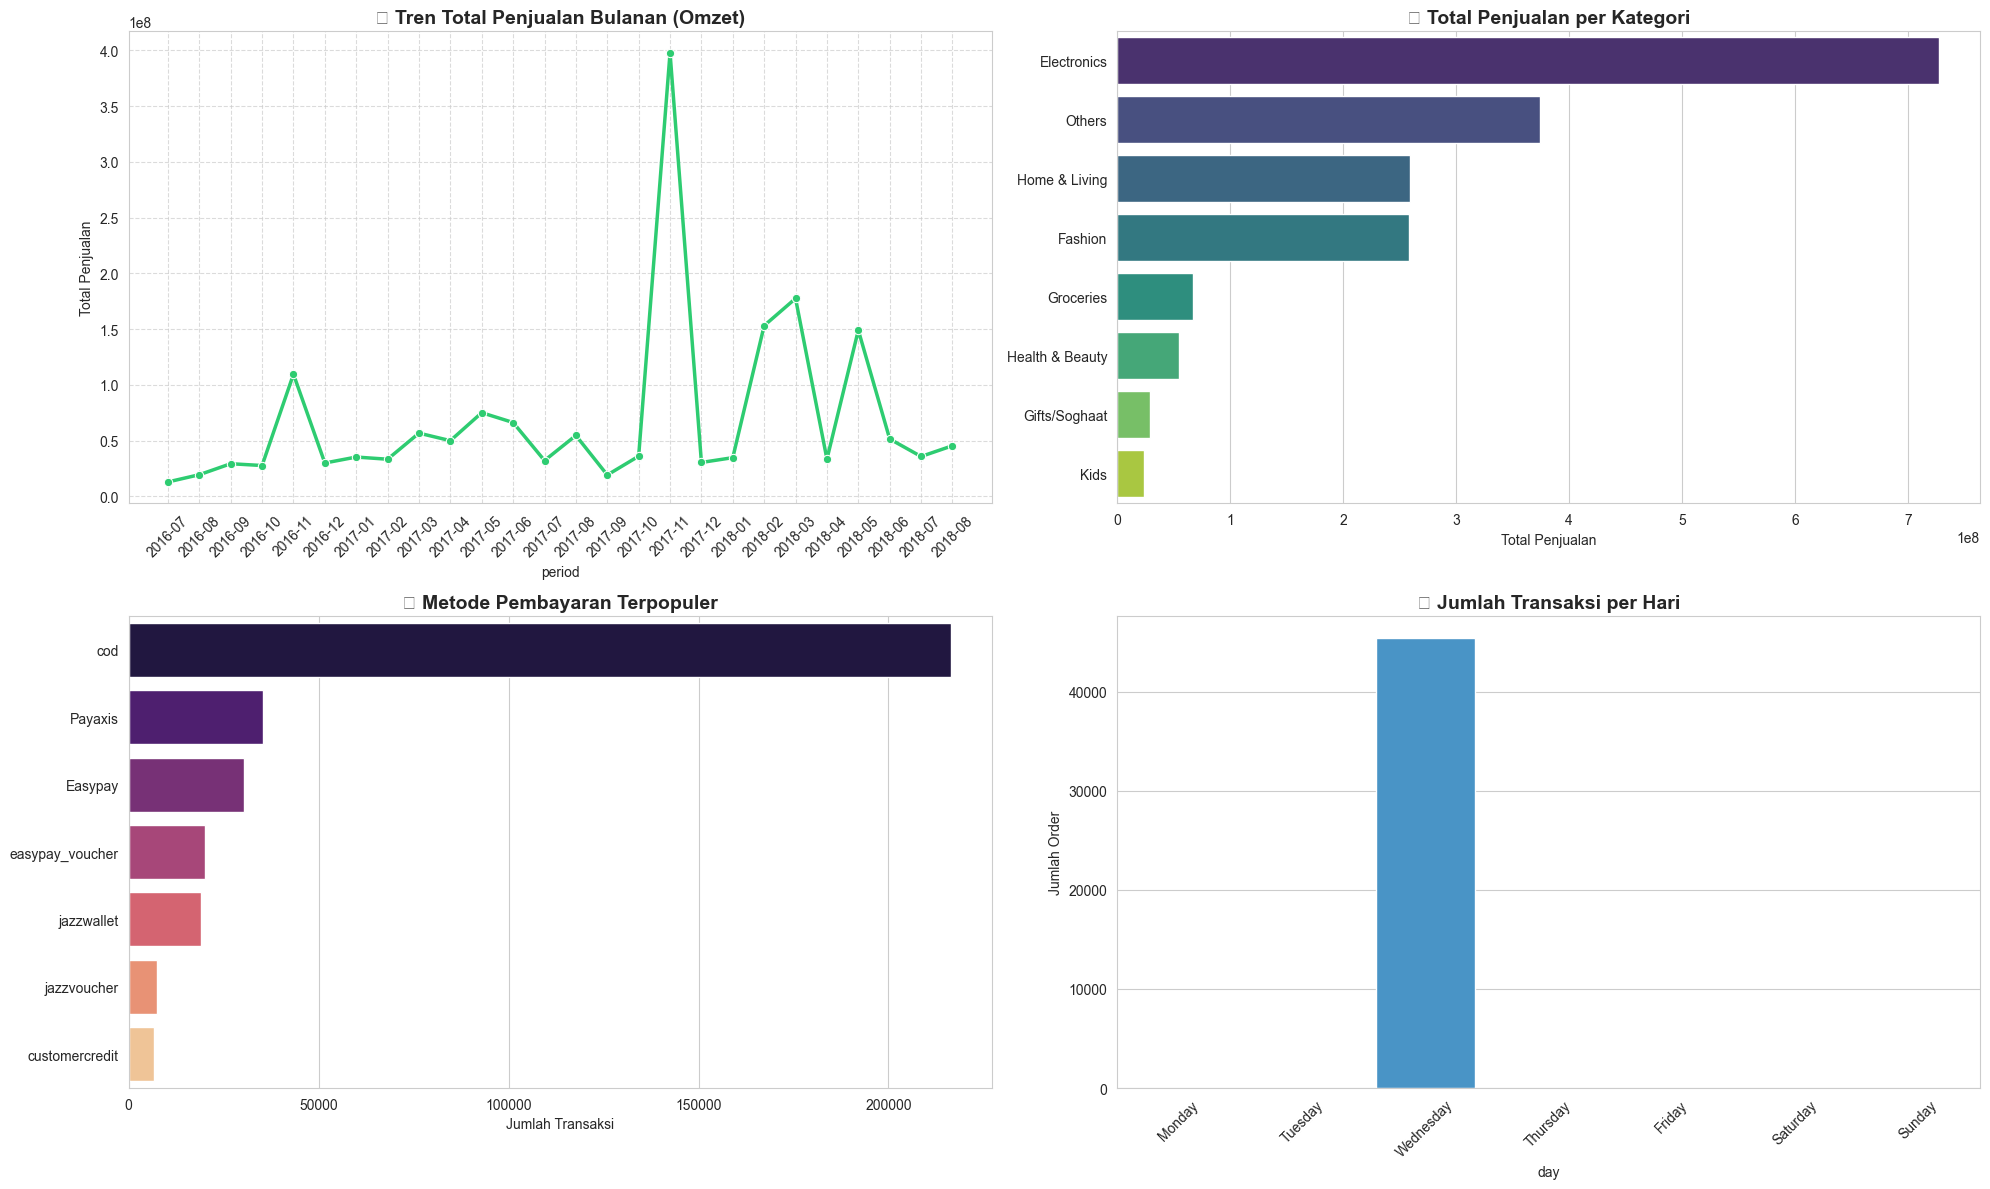

Dashboard berhasil dibuat dan disimpan sebagai 'dashboard_ecommerce.png'


In [20]:
print("=== PERSIAPAN DATA VISUALISASI ===")

# 1. QUERY DATA GABUNGAN (JOIN)
# Kita menggabungkan Tabel Fakta dengan Dimensi Waktu dan Produk
query_analysis = """
SELECT 
    f.transaction_id,
    f.grand_total,
    f.qty_ordered,
    f.payment_method,
    d.year,
    d.month,
    d.day_name,
    p.category_group
FROM dwh.fact_sales f
JOIN dwh.dim_date d ON f.date_id = d.date_id
JOIN dwh.dim_product p ON f.product_id = p.product_id;
"""

# Ambil data dari database
with engine.connect() as conn:
    df_viz = pd.read_sql(text(query_analysis), conn)

print(f"✅ Data berhasil ditarik! Total baris untuk analisis: {len(df_viz):,}")
print("\n[Preview Dataset Bersih]")
display(df_viz.head())

# --- MULAI MEMBUAT GRAFIK ---
print("\nGenerating Dashboard...")
sns.set_style("whitegrid")
plt.figure(figsize=(20, 12)) # Ukuran kanvas besar

# GRAFIK 1: TREN PENJUALAN BULANAN (Line Chart)
# Grouping data berdasarkan Tahun dan Bulan
df_trend = df_viz.groupby(['year', 'month'])['grand_total'].sum().reset_index()
df_trend['period'] = df_trend['year'].astype(int).astype(str) + "-" + df_trend['month'].astype(int).astype(str).str.zfill(2)
df_trend = df_trend.sort_values(['year', 'month'])

plt.subplot(2, 2, 1)
sns.lineplot(data=df_trend, x='period', y='grand_total', marker='o', linewidth=2.5, color='#2ecc71')
plt.title('📈 Tren Total Penjualan Bulanan (Omzet)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Penjualan')
plt.grid(True, linestyle='--', alpha=0.7)

# GRAFIK 2: PENJUALAN PER KATEGORI (Bar Chart)
# Mencari kategori mana yang paling menghasilkan uang
df_cat = df_viz.groupby('category_group')['grand_total'].sum().reset_index().sort_values('grand_total', ascending=False)

plt.subplot(2, 2, 2)
sns.barplot(data=df_cat, x='grand_total', y='category_group', palette='viridis')
plt.title('🏆 Total Penjualan per Kategori', fontsize=14, fontweight='bold')
plt.xlabel('Total Penjualan')
plt.ylabel('')

# GRAFIK 3: METODE PEMBAYARAN FAVORIT (Bar Chart)
df_pay = df_viz['payment_method'].value_counts().reset_index().head(7) # Ambil Top 7
df_pay.columns = ['method', 'count']

plt.subplot(2, 2, 3)
sns.barplot(data=df_pay, x='count', y='method', palette='magma')
plt.title('💳 Metode Pembayaran Terpopuler', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('')

# GRAFIK 4: HARI PALING SIBUK (Bar Chart)
# Mengurutkan hari dari Senin - Minggu
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_day = df_viz['day_name'].value_counts().reindex(days_order).reset_index()
df_day.columns = ['day', 'orders']

plt.subplot(2, 2, 4)
sns.barplot(data=df_day, x='day', y='orders', color='#3498db')
plt.title('📅 Jumlah Transaksi per Hari', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Jumlah Order')

plt.tight_layout()
plt.savefig('dashboard_ecommerce.png') # Simpan gambar otomatis
plt.show()

print("Dashboard berhasil dibuat dan disimpan sebagai 'dashboard_ecommerce.png'")

=== MEMBUKTIKAN HUBUNGAN: TRANSAKSI VS HARI LIBUR ===

[BUKTI 1: Daftar Hari Libur yang Terekam di Transaksi]


,holiday_name,total_transactions,total_revenue
1,Independence Day,2897,19751654.79
2,Pakistan Day,1892,9401394.77
3,January 1 Bank Holiday,661,6919265.31
4,Eid al-Adha Day 2,251,4773974.60
5,New Year's Eve,446,2904567.37


C:\Users\khali\AppData\Local\Temp\ipykernel_33664\3795687841.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_holidays, x='total_revenue', y='holiday_name', palette='Reds_r')
C:\Users\khali\AppData\Local\Temp\ipykernel_33664\3795687841.py:50: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khali\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


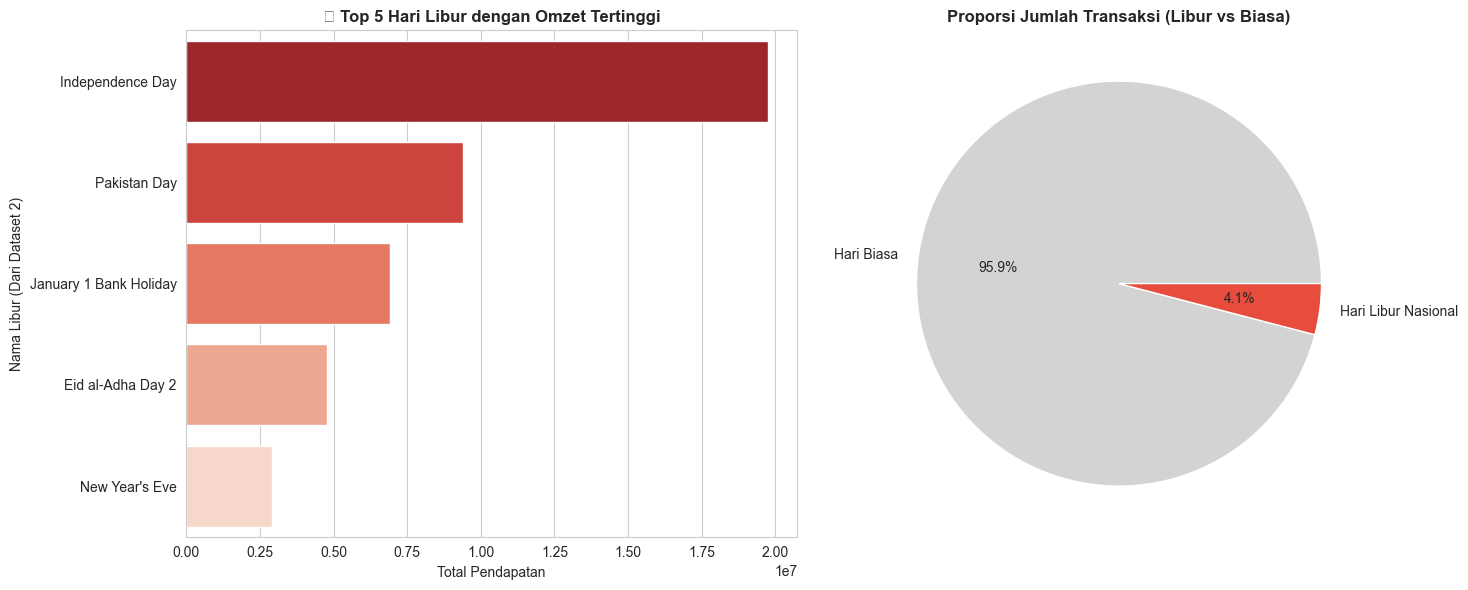

In [22]:
print("=== MEMBUKTIKAN HUBUNGAN: TRANSAKSI VS HARI LIBUR ===")

# 1. QUERY KHUSUS
# Kita ambil data transaksi, tapi kali ini dikelompokkan berdasarkan
# status libur (is_holiday) dan nama liburnya (holiday_name).
query_holiday_effect = """
SELECT 
    d.is_holiday,
    d.holiday_name,
    COUNT(f.transaction_id) as total_transactions,
    SUM(f.grand_total) as total_revenue
FROM dwh.fact_sales f
JOIN dwh.dim_date d ON f.date_id = d.date_id
GROUP BY d.is_holiday, d.holiday_name
ORDER BY total_revenue DESC;
"""

with engine.connect() as conn:
    df_hol = pd.read_sql(text(query_holiday_effect), conn)

# Pisahkan data untuk visualisasi
# Data 1: Perbandingan Global (Libur vs Bukan)
df_compare = df_hol.groupby('is_holiday')[['total_revenue', 'total_transactions']].sum().reset_index()
df_compare['Label'] = df_compare['is_holiday'].map({True: 'Hari Libur Nasional', False: 'Hari Biasa'})

# Data 2: Top 5 Liburan Paling Cuan (Hanya ambil yang is_holiday = True)
df_top_holidays = df_hol[df_hol['is_holiday'] == True].head(5)

# --- VISUALISASI ---
plt.figure(figsize=(15, 6))

# GRAFIK A: Tabel Data (Langsung kita tampilkan angkanya)
# Ini membuktikan 'holiday_name' dari Dataset 2 berhasil masuk ke Dataset Utama
print("\n[BUKTI 1: Daftar Hari Libur yang Terekam di Transaksi]")
display(df_top_holidays[['holiday_name', 'total_transactions', 'total_revenue']])

# GRAFIK B: Top 5 Liburan dengan Penjualan Tertinggi (Bar Chart)
plt.subplot(1, 2, 1)
sns.barplot(data=df_top_holidays, x='total_revenue', y='holiday_name', palette='Reds_r')
plt.title('🏆 Top 5 Hari Libur dengan Omzet Tertinggi', fontsize=12, fontweight='bold')
plt.xlabel('Total Pendapatan')
plt.ylabel('Nama Libur (Dari Dataset 2)')

# GRAFIK C: Rata-rata Transaksi (Pie Chart atau Bar Kecil)
# Kita lihat proporsinya
plt.subplot(1, 2, 2)
plt.pie(df_compare['total_transactions'], labels=df_compare['Label'], autopct='%1.1f%%', colors=['lightgray', '#e74c3c'])
plt.title('Proporsi Jumlah Transaksi (Libur vs Biasa)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
print("=== AUDIT STRUKTUR & DIMENSI DATA WAREHOUSE ===")

tables_to_check = ['dim_date', 'dim_product', 'dim_customer', 'fact_sales']

with engine.connect() as conn:
    
    for tbl in tables_to_check:
        print(f"\n📂 TABEL: dwh.{tbl}")
        
        # Ambil Nama Kolom
        cols_query = f"""
        SELECT column_name 
        FROM information_schema.columns 
        WHERE table_schema = 'dwh' AND table_name = '{tbl}'
        ORDER BY ordinal_position;
        """
        cols = [row[0] for row in conn.execute(text(cols_query))]
        
        # Tampilkan Metadata
        print(f"   ► Dimensi: {n_rows:,} Baris × {len(cols)} Kolom")
        print(f"   ► Daftar Fitur: {cols}")
        
        # Tampilkan Sampel
        print(f"   ► Preview Isi:")
        df_sample = pd.read_sql(text(f"SELECT * FROM dwh.{tbl} LIMIT 10"), conn)
        display(df_sample)

    # BAGIAN 3: MASTER DATASET VIEW
    print("\n" + "="*60)
    print("MASTER DATASET (PREVIEW GABUNGAN)")
    print("="*60)
    
    # Query Gabungan
    query_master = """
    SELECT 
        f.transaction_id, f.grand_total, f.status, f.payment_method, -- Fakta
        d.date_id, d.day_name, d.month, d.year, d.is_holiday,        -- Dim Date
        p.category_original, p.category_group,                       -- Dim Product
        c.join_date, c.total_orders                                  -- Dim Customer
    FROM dwh.fact_sales f
    LEFT JOIN dwh.dim_date d ON f.date_id = d.date_id
    LEFT JOIN dwh.dim_product p ON f.product_id = p.product_id
    LEFT JOIN dwh.dim_customer c ON f.customer_id = c.customer_id
    LIMIT 5;
    """
    df_master = pd.read_sql(text(query_master), conn)
    
    # Hitung total kolom Master secara manual dari DataFrame hasil query
    master_cols = len(df_master.columns)
    
    print(f"ESTIMASI DIMENSI MASTER DATASET:")
    print(f"► Total Baris : {total_fact_rows:,} (Sama dengan Tabel Fakta)")
    print(f"► Total Kolom : {master_cols} Fitur Gabungan")
    print(f"► Status      : SIAP UNTUK MACHINE LEARNING / BI")
    
    display(df_master)


=== AUDIT STRUKTUR & DIMENSI DATA WAREHOUSE ===

📂 TABEL: dwh.dim_date
   ► Dimensi: 346,560 Baris × 7 Kolom
   ► Daftar Fitur: ['date_id', 'year', 'month', 'day', 'day_name', 'is_holiday', 'holiday_name']
   ► Preview Isi:


,date_id,year,month,day,day_name,is_holiday,holiday_name
0,2016-07-01,2016.0,7.0,1.0,Friday,True,July 1 Bank Holiday
1,2016-07-02,2016.0,7.0,2.0,Saturday,False,None
2,2016-07-03,2016.0,7.0,3.0,Sunday,False,None
3,2016-07-04,2016.0,7.0,4.0,Monday,False,None
4,2016-07-05,2016.0,7.0,5.0,Tuesday,True,Eid-ul-Fitr (holiday)
5,2016-07-06,2016.0,7.0,6.0,Wednesday,True,Eid-ul-Fitr Day 1
6,2016-07-07,2016.0,7.0,7.0,Thursday,True,Eid-ul-Fitr Day 2
7,2016-07-08,2016.0,7.0,8.0,Friday,True,Eid-ul-Fitr Day 3
8,2016-07-09,2016.0,7.0,9.0,Saturday,True,Eid-ul-Fitr Day 4
9,2016-07-10,2016.0,7.0,10.0,Sunday,True,Eid-ul-Fitr (holiday)



📂 TABEL: dwh.dim_product
   ► Dimensi: 346,560 Baris × 3 Kolom
   ► Daftar Fitur: ['product_id', 'category_original', 'category_group']
   ► Preview Isi:


,product_id,category_original,category_group
0,HAS_Golden Bluetooth Smart Watch With GSM Slot...,Mobiles & Tablets,Electronics
1,shopfever_JA868HB0H7XN0NAFAMZ,Beauty & Grooming,Health & Beauty
2,FSMS_WP-927-White,Mobiles & Tablets,Electronics
3,MEFQKS59AD3C3742B7B-M,Men's Fashion,Fashion
4,joko_NJEL30005-B,Beauty & Grooming,Health & Beauty
5,BB_Red & Black Football Design Beanbag,Home & Living,Others
6,PlanetX_PO-9025,Kids & Baby,Kids
7,Paramount_9789694946559,Books,Others
8,WOFSAN59ACD8BCC364E,Women's Fashion,Fashion
9,memsaab_skb-998,Women's Fashion,Fashion



📂 TABEL: dwh.dim_customer
   ► Dimensi: 346,560 Baris × 3 Kolom
   ► Daftar Fitur: ['customer_id', 'join_date', 'total_orders']
   ► Preview Isi:


,customer_id,join_date,total_orders
0,65948.0,2017-11-09,4
1,90186.0,2018-02-20,37
2,18947.0,2016-11-23,2
3,79253.0,2017-11-24,3
4,111707.0,2018-06-26,3
5,20200.0,2016-11-24,4
6,89436.0,2018-02-18,13
7,29299.0,2016-12-20,1
8,7801.0,2016-09-27,62
9,30022.0,2016-12-31,9



📂 TABEL: dwh.fact_sales
   ► Dimensi: 346,560 Baris × 10 Kolom
   ► Daftar Fitur: ['transaction_id', 'date_id', 'product_id', 'customer_id', 'price', 'qty_ordered', 'grand_total', 'discount_amount', 'status', 'payment_method']
   ► Preview Isi:


,transaction_id,date_id,product_id,customer_id,price,qty_ordered,grand_total,discount_amount,status,payment_method
0,211131.0,2016-07-01,kreations_YI 06-L,1.0,1950.0,1.0,1950.0,0.0,complete,cod
1,211135.0,2016-07-01,kcc_krone deal,4.0,360.0,1.0,60.0,300.0,complete,cod
2,211138.0,2016-07-01,kcc_krone deal,7.0,360.0,1.0,60.0,300.0,complete,cod
3,211139.0,2016-07-01,UK_Namkino Mix Nimco 400 Gms,6.0,170.0,1.0,170.0,0.0,complete,cod
4,211142.0,2016-07-01,"GFC_Pedestal Myga Cross Base (Special Guard) 24""",9.0,5500.0,1.0,5500.0,0.0,complete,cod
5,211143.0,2016-07-01,BK1070200PL,10.0,210.0,1.0,366.0,0.0,received,cod
6,211144.0,2016-07-01,BK1130200CF,10.0,156.0,1.0,366.0,0.0,received,cod
7,211145.0,2016-07-01,kcc_Sultanat,11.0,120.0,1.0,120.0,0.0,complete,ublcreditcard
8,211146.0,2016-07-01,kcc_glamour deal,12.0,320.0,1.0,0.0,0.0,complete,customercredit
9,211149.0,2016-07-01,cr_DATES WITH CASHEW-400 GM,13.0,420.0,1.0,1270.0,0.0,complete,cod



MASTER DATASET (PREVIEW GABUNGAN)
ESTIMASI DIMENSI MASTER DATASET:
► Total Baris : 346,560 (Sama dengan Tabel Fakta)
► Total Kolom : 13 Fitur Gabungan
► Status      : SIAP UNTUK MACHINE LEARNING / BI


,transaction_id,grand_total,status,payment_method,date_id,day_name,month,year,is_holiday,category_original,category_group,join_date,total_orders
0,211131.0,1950.0,complete,cod,2016-07-01,Friday,7.0,2016.0,True,Women's Fashion,Fashion,2016-07-01,2
1,211135.0,60.0,complete,cod,2016-07-01,Friday,7.0,2016.0,True,Beauty & Grooming,Health & Beauty,2016-07-01,475
2,211138.0,60.0,complete,cod,2016-07-01,Friday,7.0,2016.0,True,Beauty & Grooming,Health & Beauty,2016-07-01,5
3,211139.0,170.0,complete,cod,2016-07-01,Friday,7.0,2016.0,True,Soghaat,Gifts/Soghaat,2016-07-01,2
4,211142.0,5500.0,complete,cod,2016-07-01,Friday,7.0,2016.0,True,Appliances,Home & Living,2016-07-01,1
